### Подготовка данных


In [66]:
import os
import shutil
from pathlib import Path
from PIL import Image
import numpy as np
import joblib
import pandas as pd
from skimage import measure
from skimage.measure import shannon_entropy
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

IMG_SIZE = (512, 256)  # до какого размера были сжаты изображения

## Начнем все с начала
### Подготовка данных
Объединим датасеты 8 000 и 800 с разных датасетов в один и разметим их, чтобы при разбиении равномерно их распределить.

In [2]:
home = '/home/slava/Downloads/Diplom9/Diplom'

diff_spot_actual_bunner_dir = home + '/diff_spot_bunner_actual' # скриншоты diff spot 3774
diff_spot_actual_dir = home + '/diff_spot_actual' # скриншоты diff spot 3774
bugs_actual_dir = home + '/bugs_actual' # скриншоты с пропавшим элементом
bugs_actual_2_dir = home + '/bugs_actual_2_increase_ds' # скриншоты с пропавшим элементом 2 увеличенный датта сет
bugs_change_color_actual_dir = home + '/bugs_change_color_actual' # скриншоты с изменением цвета элемента
bugs_elemets_move_actual_dir = home + '/bugs_elemets_move_actual' # скриншоты с изменением положения элемента
bugs_elemets_move_actual_2_dir = home + '/bugs_actual_elemets_move_shift_2_increase_ds' # скриншоты с изменением положения элемента 2 увеличенный датта сет
not_bugs_dynamic_elements_actual_dir = home + '/not_bugs_dynamic_elements_actual' # скриншоты с динамическими элементами
not_bug_banners_actual_dir = home + '/not_bug_banners_actual' # скриншоты с появившимся баннерами
not_bug_banners_actual_2_dir = home + '/not_bug_banners_actual_2_increase_ds' # скриншоты с появившимся баннерами 2 увеличенный датта сет

In [3]:
data = []

def create_dataset_1(path_actual, label):
    for filename in os.listdir(path_actual):
        actual_path = os.path.join(path_actual, filename)
        expected_path = os.path.join(path_actual.replace('actual', 'expected'), filename.replace('aug_', ''))
        if os.path.isfile(actual_path) and os.path.isfile(expected_path):
            data.append({
                'actual': str(actual_path),
                'expected': str(expected_path),
                'filename': str(filename),
                'label': label
            })
        else:
            print(f"Пропущен файл {filename}: один из файлов не существует")

def create_dataset_2(path_actual, label):
    for filename in os.listdir(path_actual):
        actual_path = os.path.join(path_actual, filename)
        expected_path = os.path.join(path_actual.replace('actual', 'expected'), filename.replace('actual', 'expected'))
        if os.path.isfile(actual_path) and os.path.isfile(expected_path):
            data.append({
                'actual': str(actual_path),
                'expected': str(expected_path),
                'filename': str(filename),
                'label': label
            })
        else:
            print(f"Пропущен файл {filename}: один из файлов не существует")

create_dataset_1(diff_spot_actual_bunner_dir, 0)
create_dataset_1(diff_spot_actual_dir, 1)
create_dataset_2(bugs_actual_dir, 1)
create_dataset_2(bugs_actual_2_dir, 1)
create_dataset_2(bugs_change_color_actual_dir, 1)
create_dataset_2(bugs_elemets_move_actual_dir, 1)
create_dataset_2(bugs_elemets_move_actual_2_dir, 1)
create_dataset_2(not_bugs_dynamic_elements_actual_dir, 0)
create_dataset_2(not_bug_banners_actual_dir, 0)
create_dataset_2(not_bug_banners_actual_2_dir, 0)
                
df = pd.DataFrame(data)
df.to_csv('labels_all_in_one.csv', index=False)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   actual    8366 non-null   str  
 1   expected  8366 non-null   str  
 2   filename  8366 non-null   str  
 3   label     8366 non-null   int64
dtypes: int64(1), str(3)
memory usage: 261.6 KB


In [5]:
print(f"Всего пар: {len(df)}")
print(f"С багами: {df['label'].sum()}")
print(f"Без багов: {len(df) - df['label'].sum()}")

Всего пар: 8366
С багами: 4174
Без багов: 4192


In [6]:
IMG_SIZE = (512, 256)  # до какого размера сжимаем изображения

def compress_image(path):
    img = Image.open(path).convert('L')  # конвертируем в grayscale
    img = img.resize(IMG_SIZE)  # сжимаем
    return np.array(img) / 255.0  # нормализация

X = []
y = []
actual_images = []
expected_images = []

for _, row in df.iterrows():
    actual = compress_image(row['actual'])
    expected = compress_image(row['expected'])

    # Вычисляем абсолютную разницу (в градациях серого)
    diff = np.abs(actual - expected)  # форма: (h, w)
    
    X.append(diff)
    y.append(row['label'])

X = np.array(X)  # вертор разницы
y = np.array(y)  # метки: 0 или 1

In [7]:
print(f"Форма X: {X.shape}")
print(f"Тип данных X: {X.dtype}")
print(f"Количество образцов: {len(X)}")
print(f"Диапазон значений: min={X.min():.4f}, max={X.max():.4f}")
print(f"Среднее значение: {X.mean():.4f}")
print(f"Стандартное отклонение: {X.std():.4f}")

Форма X: (8366, 256, 512)
Тип данных X: float64
Количество образцов: 8366
Диапазон значений: min=0.0000, max=1.0000
Среднее значение: 0.0177
Стандартное отклонение: 0.1028


In [8]:
def crop_to_content_with_coords(image, threshold=0.01):
    """
    Обрезает изображение до области с информацией и возвращает координаты.
    
    Returns:
        cropped: обрезанное изображение
        top_left: кортеж (y, x) — координаты верхнего левого угла обрезанной области 
                  относительно исходного изображения (до применения padding)
    """
    mask = image > threshold
    
    if not mask.any():
        return np.zeros((10, 10)), (0, 0)
    
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    
    # Сохраняем координаты ДО добавления padding
    top_left_y = rmin
    top_left_x = cmin
    
    padding = 10
    rmin = max(0, rmin - padding)
    rmax = min(image.shape[0], rmax + padding)
    cmin = max(0, cmin - padding)
    cmax = min(image.shape[1], cmax + padding)
    
    cropped = image[rmin:rmax, cmin:cmax]
    top_left = (top_left_y, top_left_x)
    
    return cropped, top_left

X_cropped = []
X_coords = []
for img in X:
    cropped, coords = crop_to_content_with_coords(img)
    X_cropped.append(cropped)
    X_coords.append(coords)

# Проверяем результаты
print(f"Размеры до обрезки: {X[0].shape}")
print(f"Размеры после обрезки: {X_cropped[0].shape}")
print(f"Пример координат: {X_coords[0]}")
print(f"Средний размер после обрезки: {np.mean([img.shape for img in X_cropped])}")

Размеры до обрезки: (256, 512)
Размеры после обрезки: (73, 108)
Пример координат: (np.int64(107), np.int64(71))
Средний размер после обрезки: 129.8135907243605


### Извлечение признаков для классической модели
Мы с ними работали, добавим все, чтобы было что убирать. Последние 10 признаков из 32 привносили +1% качества. Оптимальное количество для подбора сложности.

In [11]:
def extract_features(diff_image, top_left):
    """
    Извлекает признаки из diff-области.
    
    Parameters:
        diff_image: обрезанное diff-изображение
        top_left: кортеж (y, x) координат относительно исходного скриншота
    """
    features = {}
    
    h, w = diff_image.shape
    
    # 1. Геометрические признаки (bounding box)
    features['width'] = w
    features['height'] = h
    features['area_bbox'] = w * h
    features['aspect_ratio'] = w / h if h > 0 else 0
    features['relative_area'] = (w * h) / (IMG_SIZE[0] * IMG_SIZE[1])
    
    # 2. Позиционные признаки
    features['top_left_y'] = top_left[0]
    features['top_left_x'] = top_left[1]
    features['center_y_norm'] = (top_left[0] + h/2) / IMG_SIZE[1]
    features['center_x_norm'] = (top_left[1] + w/2) / IMG_SIZE[0]
    
    # 3. Признаки интенсивности
    features['mean_intensity'] = np.mean(diff_image)
    features['std_intensity'] = np.std(diff_image)
    features['max_intensity'] = np.max(diff_image)
    features['sum_intensity'] = np.sum(diff_image)
    features['nonzero_ratio'] = np.count_nonzero(diff_image) / diff_image.size
    
    # 4. Морфологические признаки (связные компоненты)
    binary = (diff_image > 0.01).astype(np.uint8)
    labeled = measure.label(binary, connectivity=2)
    regions = measure.regionprops(labeled)
    
    features['num_components'] = len(regions)
    
    if len(regions) > 0:
        areas = [r.area for r in regions]
        features['largest_component_area'] = max(areas)
        features['largest_component_ratio'] = max(areas) / (np.count_nonzero(binary) + 1)
        features['mean_component_area'] = np.mean(areas)
        features['std_component_area'] = np.std(areas) if len(areas) > 1 else 0
        
        # Характеристики крупнейшей компоненты
        largest_region = max(regions, key=lambda r: r.area)
        features['largest_compactness'] = (largest_region.perimeter ** 2) / (4 * np.pi * largest_region.area + 1)
        features['largest_eccentricity'] = largest_region.eccentricity
        features['largest_solidity'] = largest_region.solidity  # area / convex_area
        features['largest_extent'] = largest_region.extent  # area / bbox_area
        features['largest_orientation'] = largest_region.orientation
    else:
        features['largest_component_area'] = 0
        features['largest_component_ratio'] = 0
        features['mean_component_area'] = 0
        features['std_component_area'] = 0
        features['largest_compactness'] = 0
        features['largest_eccentricity'] = 0
        features['largest_solidity'] = 0
        features['largest_extent'] = 0
        features['largest_orientation'] = 0
    
    # 5. Текстурные признаки
    # Приводим к одному размеру для текстурного анализа
    resized = resize(diff_image, (32, 32), anti_aliasing=True)
    
    features['entropy'] = shannon_entropy(resized + 1e-10)
    
    # Статистики проекций
    row_proj = np.sum(resized, axis=1)
    col_proj = np.sum(resized, axis=0)
    features['std_row_projection'] = np.std(row_proj)
    features['std_col_projection'] = np.std(col_proj)
    features['max_row_projection'] = np.max(row_proj)
    features['max_col_projection'] = np.max(col_proj)
    
    return features


def create_feature_dataset(X_diff, X_coords):
    """
    Создает датафрейм с признаками для всех образцов.
    
    Parameters:
        X_diff: список обрезанных diff-изображений
        X_coords: список кортежей (y, x) верхнего левого угла
    """
    all_features = []
    
    for i, (diff_img, coords) in enumerate(zip(X_diff, X_coords)):
        features = extract_features(diff_img, coords)
        features['sample_id'] = i
        all_features.append(features)
    
    df = pd.DataFrame(all_features)
    return df

In [12]:
def compute_symmetry_score_enhanced(diff_images):
    """
    Делит diff-область пополам по вертикали и горизонтали,
    сравнивает половинки через среднюю абсолютную разницу.
    Возвращает минимальную разницу (0 = полная симметрия).
    Улучшенная версия с нормализацией и поиском симметрии с небольшим сдвигом
    """
    symmetry_score = []

    for diff_image in diff_images:
        h, w = diff_image.shape
        
        # Нормализация для устойчивости
        if diff_image.max() > 0:
            diff_norm = diff_image / diff_image.max()
        else:
            symmetry_score.append(0)
            continue
        
        best_score = float('inf')
        
        # Пробуем разные точки разделения для поиска наилучшей симметрии
        for offset in range(-2, 3):  # Небольшой сдвиг
            mid_w = (w // 2) + offset
            if mid_w <= 0 or mid_w >= w:
                continue
                
            left = diff_norm[:, :mid_w]
            right = np.fliplr(diff_norm[:, mid_w:2*mid_w]) if 2*mid_w <= w else np.fliplr(diff_norm[:, w-mid_w:])
            
            # Приводим к одному размеру
            min_w = min(left.shape[1], right.shape[1])
            if min_w > 0:
                vert_diff = np.mean(np.abs(left[:, :min_w] - right[:, :min_w]))
                best_score = min(best_score, vert_diff)
        
        symmetry_score.append(best_score)
    
    return symmetry_score

In [13]:
def detect_duplicated_pattern(diff_images):
    """
    Ищет повторяющиеся вертикальные паттерны в diff-изображении.
    Возвращает score (0 = идеальное повторение, т.е. явный сдвиг)
    """
    duplicate_pattern_best_score = []
    duplicate_pattern_best_shift = []
    for diff_image in diff_images:
        h, w = diff_image.shape
        
        if h < 10 or w < 10:
            return 1.0
        
        best_score = 1.0
        best_shift = 0
        
        # Ищем повторяющиеся колонки/блоки
        # Пробуем разные сдвиги (половина ширины и другие)
        for shift_ratio in [0.5, 0.33, 0.25]:  # Проверяем разные соотношения
            shift = int(w * shift_ratio)
            if shift < 10:
                continue
                
            # Сравниваем левую часть с правой (со сдвигом)
            for start in range(0, w - shift, max(1, shift // 4)):
                left_block = diff_image[:, start:start + shift]
                right_block = diff_image[:, start + shift:start + 2*shift]
                
                if right_block.shape[1] >= shift * 0.8:
                    # Обрезаем до одинакового размера
                    min_w = min(left_block.shape[1], right_block.shape[1])
                    if min_w > 5:
                        # Нормализуем
                        left_norm = left_block[:, :min_w].astype(float)
                        right_norm = right_block[:, :min_w].astype(float)
                        
                        if left_norm.max() > 0:
                            left_norm /= left_norm.max()
                        if right_norm.max() > 0:
                            right_norm /= right_norm.max()
                        
                        similarity = np.mean(np.abs(left_norm - right_norm))
                        
                        if similarity < best_score:
                            best_score = similarity
                            best_shift = shift
        
        duplicate_pattern_best_score.append(best_score)
        duplicate_pattern_best_shift.append(best_shift)
    return duplicate_pattern_best_score, duplicate_pattern_best_shift

In [14]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

Размер датафрейма: (8366, 33)
Количество признаков: 32


In [15]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 3774:
        subtype_labels.append('diff_spot_dataset')
    else:
        subtype_labels.append('netology')

subtype_labels = np.array(subtype_labels)

In [16]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

# Первое разбиение: train (60%) и temp (40%)
X_train, X_temp, y_train, y_temp, sub_train, sub_temp, idx_train, idx_temp = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.4,          # 40% уходит в temp
    stratify=subtype_labels,
    random_state=69
)

# Второе разбиение: temp делим на val (50% от temp) и test (50% от temp)
X_val, X_test, y_val, y_test, sub_val, sub_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, sub_temp, idx_temp,
    test_size=0.5,          # 50% от temp → 20% от общего объёма
    stratify=sub_temp,
    random_state=69
)

# Итоговые размеры:
# train – 60%, val – 20%, test – 20%

In [17]:
X_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   width                          8366 non-null   int64  
 1   height                         8366 non-null   int64  
 2   area_bbox                      8366 non-null   int64  
 3   aspect_ratio                   8366 non-null   float64
 4   relative_area                  8366 non-null   float64
 5   top_left_y                     8366 non-null   int64  
 6   top_left_x                     8366 non-null   int64  
 7   center_y_norm                  8366 non-null   float64
 8   center_x_norm                  8366 non-null   float64
 9   mean_intensity                 8366 non-null   float64
 10  std_intensity                  8366 non-null   float64
 11  max_intensity                  8366 non-null   float64
 12  sum_intensity                  8366 non-null   float64
 13 

In [18]:
# Топ-10 важных признаков (по убыванию важности)
top10_features = [
    'relative_area', 'height', 'area_bbox', 'std_component_area',
    'sum_intensity', 'max_intensity', 'width', 'largest_component_area',
    'center_x_norm', 'entropy'
]

# Топ-4
top4_features = top10_features[:4]

# Топ-8
top8_features = top10_features[:8]

# Первые 8 признаков в исходном порядке DataFrame (индексы 0-7)
first8_order = [
    'width', 'height', 'area_bbox', 'aspect_ratio', 'relative_area',
    'top_left_y', 'top_left_x', 'center_y_norm'
]

# Первые 16 признаков в исходном порядке DataFrame (индексы 0-15)
first16_order = [
    'width', 'height', 'area_bbox', 'aspect_ratio', 'relative_area',
    'top_left_y', 'top_left_x', 'center_y_norm', 'center_x_norm',
    'mean_intensity', 'std_intensity', 'max_intensity', 'sum_intensity',
    'nonzero_ratio', 'num_components', 'largest_component_area'
]

# Функция для объединения топ-N и первых M без повторений
def combine_unique(list_a, list_b):
    """Возвращает list_a + элементы list_b, которых нет в list_a (сохраняя порядок list_b)."""
    seen = set(list_a)
    result = list(list_a)
    for item in list_b:
        if item not in seen:
            result.append(item)
            seen.add(item)
    return result

# Набор 1: топ-4
set1 = top4_features

# Набор 2: топ-8
set2 = top8_features

# Набор 3: топ-8 + первые 8 по порядку без повторений
set3 = combine_unique(top8_features, first8_order)

# Набор 4: топ-8 + первые 16 по порядку без повторений
set4 = combine_unique(top8_features, first16_order)

# Вывод результатов
print("Набор 1 (топ-4):")
print(set1)
print("\nНабор 2 (топ-8):")
print(set2)
print("\nНабор 3 (топ-8 + первые 8, без повторов):")
print(set3)
print("\nНабор 4 (топ-8 + первые 16, без повторов):")
print(set4)

X_train_top4 = X_train[set1]
X_val_top4 = X_val[set1]
X_train_top8 = X_train[set2]
X_val_top8 = X_val[set2]
X_train_16 = X_train[set3]
X_val_16 = X_val[set3]
X_train_24 = X_train[set4]
X_val_24 = X_val[set4]

Набор 1 (топ-4):
['relative_area', 'height', 'area_bbox', 'std_component_area']

Набор 2 (топ-8):
['relative_area', 'height', 'area_bbox', 'std_component_area', 'sum_intensity', 'max_intensity', 'width', 'largest_component_area']

Набор 3 (топ-8 + первые 8, без повторов):
['relative_area', 'height', 'area_bbox', 'std_component_area', 'sum_intensity', 'max_intensity', 'width', 'largest_component_area', 'aspect_ratio', 'top_left_y', 'top_left_x', 'center_y_norm']

Набор 4 (топ-8 + первые 16, без повторов):
['relative_area', 'height', 'area_bbox', 'std_component_area', 'sum_intensity', 'max_intensity', 'width', 'largest_component_area', 'aspect_ratio', 'top_left_y', 'top_left_x', 'center_y_norm', 'center_x_norm', 'mean_intensity', 'std_intensity', 'nonzero_ratio', 'num_components']


### Выбор модели
Сначала нужно определиться с моделью для обучения. 

Не слишком простой, чтобы получить хороший результат.

Не слишком сложной, чтобы не переобучить.

In [82]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train, y_train))
print("Val accuracy :", rf.score(X_val, y_val))

# Для обучения
y_prob_train = rf.predict_proba(X_train)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       831
           1       0.97      0.97      0.97       842

    accuracy                           0.97      1673
   macro avg       0.97      0.97      0.97      1673
weighted avg       0.97      0.97      0.97      1673

Train accuracy: 0.9852560270970313
Test accuracy : 0.9695158398087268
Log-loss (train): 0.0720
Log-loss (val): 0.0967


In [83]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=16, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train, y_train))
print("Val accuracy :", rf.score(X_val, y_val))

# Для обучения
y_prob_train = rf.predict_proba(X_train)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       831
           1       0.97      0.98      0.97       842

    accuracy                           0.97      1673
   macro avg       0.97      0.97      0.97      1673
weighted avg       0.97      0.97      0.97      1673

Train accuracy: 0.9948196851962542
Test accuracy : 0.9719067543335326
Log-loss (train): 0.0458
Log-loss (val): 0.0845


In [84]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=4, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train, y_train))
print("Val accuracy :", rf.score(X_val, y_val))

# Для обучения
y_prob_train = rf.predict_proba(X_train)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       831
           1       0.97      0.92      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.95      0.94      0.94      1673

Train accuracy: 0.9470013947001394
Test accuracy : 0.9438135086670651
Log-loss (train): 0.1518
Log-loss (val): 0.1503


In [85]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=2, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train, y_train))
print("Val accuracy :", rf.score(X_val, y_val))

# Для обучения
y_prob_train = rf.predict_proba(X_train)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       831
           1       0.94      0.87      0.90       842

    accuracy                           0.91      1673
   macro avg       0.91      0.91      0.91      1673
weighted avg       0.91      0.91      0.91      1673

Train accuracy: 0.905160390516039
Test accuracy : 0.9079497907949791
Log-loss (train): 0.2285
Log-loss (val): 0.2171


In [86]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    ccp_alpha=0.1,
    random_state=69
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train, y_train))
print("Val accuracy :", rf.score(X_val, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       831
           1       0.95      0.84      0.89       842

    accuracy                           0.90      1673
   macro avg       0.90      0.90      0.90      1673
weighted avg       0.90      0.90      0.90      1673

Train accuracy: 0.8932058178920104
Test accuracy : 0.8965929468021518
Log-loss (train): 0.2983
Log-loss (val): 0.2884


```
X_train_top4 = X_train[set1]
X_val_top4 = X_val[set1]
X_train_top8 = X_train[set2]
X_val_top8 = X_val[set2]
X_train_16 = X_train[set3]
X_val_16 = X_val[set3]
X_train_24 = X_train[set4]
X_val_24 = X_val[set4]
```

In [88]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train_top4, y_train)

y_pred = rf.predict(X_val_top4)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_top4, y_train))
print("Val accuracy :", rf.score(X_val_top4, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_top4)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_top4)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.67      0.89      0.76       831
           1       0.84      0.57      0.68       842

    accuracy                           0.73      1673
   macro avg       0.75      0.73      0.72      1673
weighted avg       0.75      0.73      0.72      1673

Train accuracy: 0.7531380753138075
Test accuracy : 0.7274357441721458
Log-loss (train): 0.4650
Log-loss (val): 0.4956


In [89]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train_top8, y_train)

y_pred = rf.predict(X_val_top8)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_top8, y_train))
print("Val accuracy :", rf.score(X_val_top8, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_top8)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_top8)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       831
           1       0.96      0.92      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.951783223749751
Test accuracy : 0.9402271368798566
Log-loss (train): 0.1216
Log-loss (val): 0.1491


In [90]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9599521817095039
Test accuracy : 0.949193066347878
Log-loss (train): 0.1103
Log-loss (val): 0.1402


In [91]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train_24, y_train)

y_pred = rf.predict(X_val_24)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_24, y_train))
print("Val accuracy :", rf.score(X_val_24, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_24)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_24)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9667264395297868
Test accuracy : 0.9545726240286909
Log-loss (train): 0.0993
Log-loss (val): 0.1310


In [92]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=16, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9840605698346284
Test accuracy : 0.949193066347878
Log-loss (train): 0.0702
Log-loss (val): 0.1301


In [93]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=4, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       831
           1       0.96      0.92      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9372384937238494
Test accuracy : 0.9372384937238494
Log-loss (train): 0.1930
Log-loss (val): 0.1877


In [94]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6, 
    min_samples_split=10,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       831
           1       0.96      0.93      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9475991233313409
Test accuracy : 0.9438135086670651
Log-loss (train): 0.1434
Log-loss (val): 0.1537


In [95]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=2,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9667264395297868
Test accuracy : 0.9485953377166766
Log-loss (train): 0.1019
Log-loss (val): 0.1373


In [96]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=6,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9619446104801753
Test accuracy : 0.9497907949790795
Log-loss (train): 0.1054
Log-loss (val): 0.1388


In [97]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=18,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9583582386929668
Test accuracy : 0.949193066347878
Log-loss (train): 0.1165
Log-loss (val): 0.1406


In [98]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=32,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9553695955369595
Test accuracy : 0.9503885236102809
Log-loss (train): 0.1259
Log-loss (val): 0.1442


In [99]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=64,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9501892807332137
Test accuracy : 0.9473998804542738
Log-loss (train): 0.1411
Log-loss (val): 0.1512


In [100]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.93      0.94       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9430165371587965
Test accuracy : 0.945008965929468
Log-loss (train): 0.1627
Log-loss (val): 0.1637


In [101]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8, 
    min_samples_split=32,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9553695955369595
Test accuracy : 0.9503885236102809
Log-loss (train): 0.1259
Log-loss (val): 0.1442


In [102]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.93      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9424188085275952
Test accuracy : 0.9456066945606695
Log-loss (train): 0.1617
Log-loss (val): 0.1630


In [103]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.93      0.94       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9432157800358637
Test accuracy : 0.945008965929468
Log-loss (train): 0.1634
Log-loss (val): 0.1640


In [104]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       831
           1       0.96      0.93      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9424188085275952
Test accuracy : 0.9444112372982666
Log-loss (train): 0.1618
Log-loss (val): 0.1628


In [105]:
rf = RandomForestClassifier(
    n_estimators=125,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.93      0.94       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.9428172942817294
Test accuracy : 0.945008965929468
Log-loss (train): 0.1629
Log-loss (val): 0.1637


In [106]:
rf = RandomForestClassifier(
    n_estimators=175,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       831
           1       0.96      0.94      0.95       842

    accuracy                           0.95      1673
   macro avg       0.95      0.95      0.95      1673
weighted avg       0.95      0.95      0.95      1673

Train accuracy: 0.942219565650528
Test accuracy : 0.9456066945606695
Log-loss (train): 0.1620
Log-loss (val): 0.1631


In [107]:
rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf = 2,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       831
           1       0.95      0.93      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9420203227734608
Test accuracy : 0.9438135086670651
Log-loss (train): 0.1627
Log-loss (val): 0.1634


In [108]:
rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf = 8,
    max_depth=8, 
    min_samples_split=128,
    random_state=69
)
rf.fit(X_train_16, y_train)

y_pred = rf.predict(X_val_16)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train_16, y_train))
print("Val accuracy :", rf.score(X_val_16, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train_16)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val_16)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       831
           1       0.95      0.93      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9418210798963937
Test accuracy : 0.9420203227734608
Log-loss (train): 0.1648
Log-loss (val): 0.1653


In [109]:
rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf = 4,
    max_depth=8, 
    min_samples_split=32,
    random_state=69
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
print("Train accuracy:", rf.score(X_train, y_train))
print("Val accuracy :", rf.score(X_val, y_val))
# Для обучения
y_prob_train = rf.predict_proba(X_train)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = rf.predict_proba(X_val)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       831
           1       0.97      0.96      0.97       842

    accuracy                           0.97      1673
   macro avg       0.97      0.97      0.97      1673
weighted avg       0.97      0.97      0.97      1673

Train accuracy: 0.9772863120143455
Test accuracy : 0.9653317393903168
Log-loss (train): 0.0936
Log-loss (val): 0.1091


### Предварительные итоги по Random Forest

#### Выбор максимальной глубины:
| max_depth | Train Acc | Val Acc | diff Acc | Train Loss | Val Loss | diff Loss |
|-----------|-----------|---------|----------|------------|----------|-----------|
| 16        | 0.99482   | 0.97191 | 2.29%    | 0.0458     | 0.0845   | -0.0387   |
| **8**     | **0.98526** | **0.96952** | **1.57%** | **0.0720** | **0.0967** | **-0.0247** |
| 4         | 0.94700   | 0.94381 | 0.32%    | 0.1518     | 0.1503   | 0.0015    |
| 2         | 0.90516   | 0.90795 | -0.28%   | 0.2285     | 0.2171   | 0.0114    |

Пока выбираем 8 как небольшой разрыв, нужно переделать в конце. Старт с глубины 2 "на пнях" с 0,9 пока нам говорит, что модель слишком сложная и запоминает все признаки.

#### Выбор оптимального количества признаков:
| Features  | Train Acc | Val Acc | diff Acc | Train Loss | Val Loss | diff Loss |
|-----------|-----------|---------|----------|------------|----------|-----------|
| Топ-4     | 0.753     | 0.727   | 2.6%     | 0.4650     | 0.4956   | -0.0306   |
| Топ-8     | 0.952     | 0.940   | 1.2%     | 0.1216     | 0.1491   | -0.0275   |
| **Топ-16**| **0.960** | **0.949** | **1.1%** | **0.1103** | **0.1402** | **-0.0299** |
| Топ-24    | 0.967     | 0.955   | 1.2%     | 0.0993     | 0.1310   | -0.0317   |
| Все       | 0.985     | 0.970   | 1.5%     | 0.0720     | 0.0967   | -0.0247   |

А вот тут явно видно, что разница сходится, а потом начинает расходиться, то есть переобучаться. Выбираем количество как ТОП-16.
Эксперименты с глубиной показывают лишь чем больше глубина, тем больше разница между Train и Val, оставим 1,1% как допустимую.
Хотя для большей точности можно взять и все, таким образом обощающая способность будет хуже, но точность улучшится.

#### Выбор оптимального min_samples_split:
| min_samples_split | Train Acc | Val Acc | diff Acc | Train Loss | Val Loss | diff Loss |
|-------------------|-----------|---------|----------|------------|----------|-----------|
| 2                 | 0.9667    | 0.9486  | 1.81%    | 0.1019     | 0.1373   | -0.0354   |
| 6                 | 0.9619    | 0.9498  | 1.21%    | 0.1054     | 0.1388   | -0.0334   |
| 10                | 0.9599    | 0.9492  | 1.07%    | 0.1103     | 0.1402   | -0.0299   |
| 18                | 0.9584    | 0.9492  | 0.92%    | 0.1165     | 0.1406   | -0.0241   |
| **32**            | **0.9554** | **0.9504** | **0.50%** | **0.1259** | **0.1442** | **-0.0183** |
| 64                | 0.9502    | 0.9474  | 0.28%    | 0.1411     | 0.1512   | -0.0101   |
| 128               | 0.9430    | 0.9450  | 0.20%    | 0.1627     | 0.1637   | -0.0010   |

Остановимся на 32, так как получаем наилучшую точность.

Выбираем n_estimators = 150, +/- 25 уже падает аккуратность, даже в таблицу выводить не буду.
min_samples_leaf = 4 прирост со значением по умолчанию 1% для всех данных

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top4)
X_val_scaled = scaler.transform(X_val_top4)

# Обучение модели логистической регрессии
lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))

# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.79      0.34      0.48       831
           1       0.58      0.91      0.71       842

    accuracy                           0.63      1673
   macro avg       0.69      0.63      0.60      1673
weighted avg       0.69      0.63      0.60      1673

Train accuracy: 0.6084877465630604
Test accuracy : 0.630005977286312
Log-loss (train): 0.6804
Log-loss (val): 0.6788


In [68]:
# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top8)
X_val_scaled = scaler.transform(X_val_top8)

# Обучение модели логистической регрессии
lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       831
           1       0.93      0.88      0.90       842

    accuracy                           0.90      1673
   macro avg       0.90      0.90      0.90      1673
weighted avg       0.90      0.90      0.90      1673

Train accuracy: 0.8878262602111975
Test accuracy : 0.9031679617453676
Log-loss (train): 0.2989
Log-loss (val): 0.2887


In [69]:
# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_16)
X_val_scaled = scaler.transform(X_val_16)

# Обучение модели логистической регрессии
lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       831
           1       0.92      0.88      0.89       842

    accuracy                           0.90      1673
   macro avg       0.90      0.90      0.90      1673
weighted avg       0.90      0.90      0.90      1673

Train accuracy: 0.8866308029487946
Test accuracy : 0.8965929468021518
Log-loss (train): 0.2779
Log-loss (val): 0.2711


In [70]:
# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_24)
X_val_scaled = scaler.transform(X_val_24)

# Обучение модели логистической регрессии
lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       831
           1       0.92      0.91      0.91       842

    accuracy                           0.91      1673
   macro avg       0.91      0.91      0.91      1673
weighted avg       0.91      0.91      0.91      1673

Train accuracy: 0.9081490336720462
Test accuracy : 0.913329348475792
Log-loss (train): 0.2277
Log-loss (val): 0.2226


In [71]:
# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Обучение модели логистической регрессии
lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       831
           1       0.93      0.95      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9356445507073122
Test accuracy : 0.9390316796174537
Log-loss (train): 0.1720
Log-loss (val): 0.1776


#### Выбор оптимального количества признаков (логистическая регрессия):
| Features | Train Acc | Val Acc | diff Acc | Train Loss | Val Loss | diff Loss |
|----------|-----------|---------|----------|------------|----------|-----------|
| top4     | 0.6085    | 0.6300  | -2.15%   | 0.6804     | 0.6788   | 0.0016    |
| top8     | 0.8878    | 0.9032  | -1.54%   | 0.2989     | 0.2887   | 0.0102    |
| top16    | 0.8866    | 0.8966  | -1.00%   | 0.2779     | 0.2711   | 0.0068    |
| top24    | 0.9081    | 0.9133  | -0.52%   | 0.2277     | 0.2226   | 0.0051    |
| **top32**| **0.9356** | **0.9390** | **-0.34%** | **0.1720** | **0.1776** | **-0.0056** |

Оказывается для логистической регрессии все признаки важны.



In [72]:
# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Обучение модели логистической регрессии
lr = LogisticRegression(
    random_state=69, 
    max_iter=1000,
    C = 0.01
)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       831
           1       0.92      0.92      0.92       842

    accuracy                           0.92      1673
   macro avg       0.92      0.92      0.92      1673
weighted avg       0.92      0.92      0.92      1673

Train accuracy: 0.9185096632795378
Test accuracy : 0.9222952779438135
Log-loss (train): 0.2171
Log-loss (val): 0.2150


In [73]:
lr = LogisticRegression(
    random_state=69, 
    max_iter=1000,
    C = 0.1
)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       831
           1       0.93      0.94      0.93       842

    accuracy                           0.93      1673
   macro avg       0.93      0.93      0.93      1673
weighted avg       0.93      0.93      0.93      1673

Train accuracy: 0.9270771069934249
Test accuracy : 0.9318589360430365
Log-loss (train): 0.1855
Log-loss (val): 0.1859


In [74]:
lr = LogisticRegression(
    random_state=69, 
    max_iter=1000,
    C = 1
)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       831
           1       0.93      0.95      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9356445507073122
Test accuracy : 0.9390316796174537
Log-loss (train): 0.1720
Log-loss (val): 0.1776


In [75]:
lr = LogisticRegression(
    random_state=69, 
    max_iter=1000,
    C = 10
)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       831
           1       0.94      0.95      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9386331938633193
Test accuracy : 0.9426180514046623
Log-loss (train): 0.1692
Log-loss (val): 0.1769


In [76]:
lr = LogisticRegression(
    random_state=69, 
    max_iter=1000,
    C = 100
)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       831
           1       0.94      0.95      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9396294082486552
Test accuracy : 0.9420203227734608
Log-loss (train): 0.1691
Log-loss (val): 0.1771


In [78]:
lr = LogisticRegression(
    random_state=69, 
    max_iter=1000,
    C = 1,
    # l1_ratio = 0.7,
    solver = 'liblinear'
)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Val accuracy :", lr.score(X_val_scaled, y_val))
# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")

# Для валидации
y_prob_val = lr.predict_proba(X_val_scaled)
loss_val = log_loss(y_val, y_prob_val)
print(f"Log-loss (val): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       831
           1       0.93      0.95      0.94       842

    accuracy                           0.94      1673
   macro avg       0.94      0.94      0.94      1673
weighted avg       0.94      0.94      0.94      1673

Train accuracy: 0.9358437935843794
Test accuracy : 0.9390316796174537
Log-loss (train): 0.1720
Log-loss (val): 0.1777


### Предварительные выводы по логистическая регрессия

#### Выбор оптимального количества признаков логистическая регрессия:
| Features | Train Acc | Val Acc | diff Acc | Train Loss | Val Loss | diff Loss |
|----------|-----------|---------|----------|------------|----------|-----------|
| top4     | 0.6085    | 0.6300  | -2.15%   | 0.6804     | 0.6788   | 0.0016    |
| top8     | 0.8878    | 0.9032  | -1.54%   | 0.2989     | 0.2887   | 0.0102    |
| top16    | 0.8866    | 0.8966  | -1.00%   | 0.2779     | 0.2711   | 0.0068    |
| top24    | 0.9081    | 0.9133  | -0.52%   | 0.2277     | 0.2226   | 0.0051    |
| **top32**| **0.9356** | **0.9390** | **-0.34%** | **0.1720** | **0.1776** | **-0.0056** |

Оказывается для логистической регрессии все признаки важны.


### Выбор параметра С:
| C     | Train Acc | Val Acc | diff Acc | Train Loss | Val Loss | diff Loss |
|-------|-----------|---------|----------|------------|----------|-----------|
| 0.01  | 0.918     | 0.922   | -0.4%    | 0.2171     | 0.2150   | 0.0021    |
| 0.1   | 0.927     | 0.932   | 0.5%     | 0.1855     | 0.1859   | -0.0004   |
| 1     | 0.936     | 0.939   | 0.3%     | 0.1720     | 0.1776   | -0.0056   |
| **10**| **0.939** | **0.943** | **-0.4%** | **0.1692** | **0.1769** | **-0.0077** |
| 100   | 0.940     | 0.942   | -0.2%    | 0.1691     | 0.1771   | -0.0080   |

При 10 результат лучше, видно, то это максимум дальше уже умегьшается.
Дополнительные параметры только ухудшают модель. Не буду приводить их пробы, так как есть RandomForest, который может дать +3%.

### Предварительные выводы по сравнению моделей и предсказанию результата тест
Random Forest явно выигрывает в метриках из-за сложности, но модель логистической регресии показывает отличные результаты обощающей способности, когда результаты на валидации больше чем на трейне! Конечно, мы виберем более лучшую модель (RandomForest), так как нам очень важно не пропустить дефект recall класса "1" и перед тестом выставим порог, чтобы получить максимальные значения для класса "1".

Но действительная ли она лучшая? Проверим на кросс валидации.

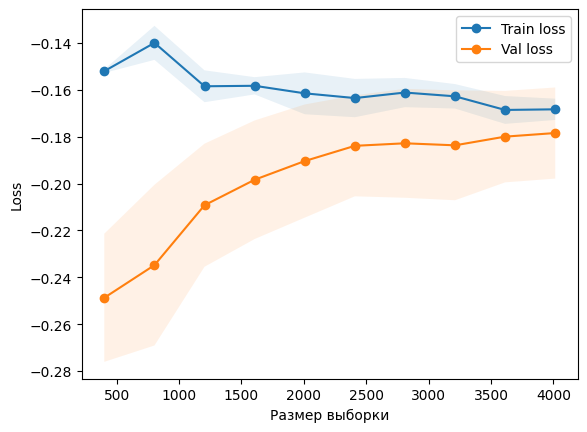

In [80]:
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(random_state=69, max_iter=1000, C=10),
    X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

# Усредняем и строим
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.plot(train_sizes, train_mean, 'o-', label='Train loss')
plt.plot(train_sizes, val_mean, 'o-', label='Val loss')
plt.xlabel('Размер выборки')
plt.ylabel('Loss')
plt.legend()
plt.show()

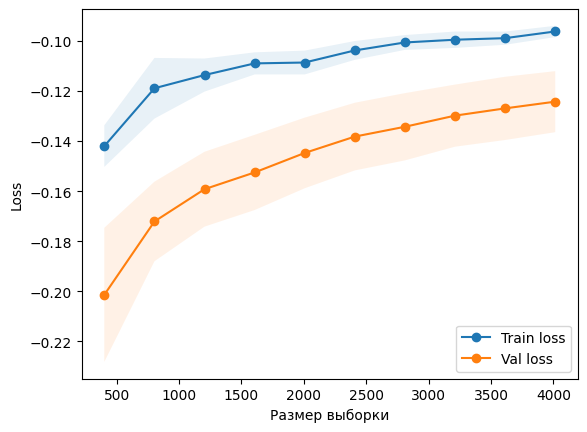

In [61]:
rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf = 4,
    max_depth=8, 
    min_samples_split=32,
    random_state=69
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

# Усредняем и строим
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.plot(train_sizes, train_mean, 'o-', label='Train loss')
plt.plot(train_sizes, test_mean, 'o-', label='Val loss')
plt.xlabel('Размер выборки')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Выводы
На кросс валидации мы видим, что логистическая регрессия намного быстрее сходится при малом количестве данных, что критично для решения на 1 микросервисе, где не так много UI. Так как нам важна обощающая способность, то выберем именно ее для финального теста и сдвинем порог на 0,1 в сторону дефектов, чтобы точно их не пропустить. 

In [121]:
# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    random_state=69, 
    max_iter=1000,
    C = 10
)
lr.fit(X_train_scaled, y_train)

y_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_custom = (y_proba >= 0.4).astype(int)

print(classification_report(y_test, y_pred_custom))
print("Train accuracy:", lr.score(X_train_scaled, y_train))
print("Test accuracy :", lr.score(X_test_scaled, y_test))

# Для обучения
y_prob_train = lr.predict_proba(X_train_scaled)
loss_train = log_loss(y_train, y_prob_train)
print(f"Log-loss (train): {loss_train:.4f}")
# Для test
y_prob_test = lr.predict_proba(X_test_scaled)
loss_val = log_loss(y_test, y_prob_test)
print(f"Log-loss (test): {loss_val:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       828
           1       0.92      0.95      0.93       846

    accuracy                           0.93      1674
   macro avg       0.93      0.93      0.93      1674
weighted avg       0.93      0.93      0.93      1674

Train accuracy: 0.9386331938633193
Test accuracy : 0.9342891278375149
Log-loss (train): 0.1692
Log-loss (test): 0.1823


### Итоги
Получен неплохой результат, не 99% процентов конечно, но зато модель точно не переобучена! Она учится на малом количестве данных и быстро сходится, что критично в реальной работе! Проста в интерпритации. И иметь recall на 95% по багам очень важно! Разница между train и test минимальна.
В файле NN_8_super_puper_increase_ds были ещё результаты нейросети, но как бы зачем? Там точность 0,87, но это совсем другой эксперимент. А необходимость ресурсов для него, делает его не востребованным.